<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
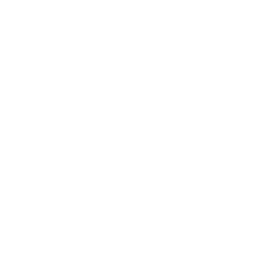
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Dokumentace schématu anotace genomických variant</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformatika / Správa dat klinické genomiky &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Zdokumentujte schéma datových sad anotací variant podobných formátu VCF, které se používají v klinickém genomickém pipeline. Pomocí PROC CONTENTS zkatalogizujte všechna anotační pole — genomické souřadnice, frekvence alel, predikované funkční dopady, klasifikace ClinVar a metriky kvality — a zajistěte tak, aby navazující nástroje pro interpretaci variant podle ACMG dostávaly vstupy se správnými datovými typy a popisky. Přibližně 5 000 záznamů variant s více než 20 anotačními sloupci se před předáním do pipeline kontroluje z hlediska integrity schématu.

## Zdroje dat

| Zdroj | Popis | Počet záznamů |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Anotované varianty odvozené z VCF | ~5 000 |
| GENE_PANEL | Definice cílového genového panelu | ~150 genů |
| QUALITY_METRICS | Kontrola kvality sekvenování pro jednotlivé vzorky | ~50 vzorků |

---

In [1]:
/* --------------------------------------------------------
   Generuj datovou sadu anotací variant podobnou VCF
   5 000 variant s poli klinických anotací
   -------------------------------------------------------- */
data variant_annotations;
    CALL streaminit(42);
    DÉLKA variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    ŠTÍTEK variant_id='Identifikátor varianty'
          chromosome='Chromozom'
          position='Genomická pozice (GRCh38)'
          ref_allele='Referenční alela'
          alt_allele='Alternativní alela'
          gene_symbol='Symbol genu HGNC'
          transcript_id='ID transkriptu Ensembl'
          consequence='Důsledek dle Sequence Ontology'
          impact='Predikovaná úroveň dopadu'
          hgvs_c='Kódující notace HGVS'
          hgvs_p='Proteinová notace HGVS'
          gnomad_af='Frekvence alely gnomAD'
          clinvar_class='Klasifikace ClinVar'
          clinvar_id='Přístupové číslo ClinVar'
          sift_score='Skóre SIFT'
          sift_pred='Predikce SIFT'
          polyphen_score='Skóre PolyPhen-2'
          polyphen_pred='Predikce PolyPhen-2'
          cadd_phred='Skóre CADD Phred'
          revel_score='Skóre REVEL Ensemble'
          genotype='Genotyp vzorku'
          allele_depth='Hloubka alternativní alely'
          read_depth='Celková hloubka čtení'
          qual_score='Skóre kvality varianty'
          filter_status='Stav filtru';
    POLE genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    POLE conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    POLE impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    POLE cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    POLE refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    POLE gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    OPAKUJ i = 1 TO 5000;
        variant_id = cat('VAR-', ZAPSAT(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', ZAPSAT(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', ZAPSAT(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', ZAPSAT(codon_pos, 4.), ref_allele, '>', alt_allele);
        KDYŽ c_idx <= 2 PAK
            hgvs_p = cat('p.', ZAPSAT(int(rand('uniform') * 800) + 1, 4.));
        JINAK hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', ZAPSAT(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        KDYŽ sift_score < 0.05 PAK sift_pred = 'DELETERIOUS';
        JINAK sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        KDYŽ polyphen_score > 0.908 PAK polyphen_pred = 'PROB_DAMAGING';
        JINAK KDYŽ polyphen_score > 0.446 PAK polyphen_pred = 'POSS_DAMAGING';
        JINAK polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        VÝSTUP;
    KONEC;
    ODSTRANIT i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
SPUSTIT;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.09 seconds
  cpu   3.09 seconds


In [2]:
/* --------------------------------------------------------
   Generuj definice cílového genového panelu
   -------------------------------------------------------- */
data gene_panel;
    CALL streaminit(42);
    DÉLKA gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    ŠTÍTEK gene_symbol='Symbol genu HGNC'
          gene_name='Celý název genu'
          chromosome='Chromozom'
          start_pos='Počáteční pozice genu'
          end_pos='Koncová pozice genu'
          panel_name='Klinický genový panel'
          disease_association='Asociované onemocnění'
          inheritance='Vzorec dědičnosti';
    POLE genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    POLE gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    POLE diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    POLE inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    OPAKUJ g = 1 TO 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', ZAPSAT(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        VÝSTUP;
    KONEC;
    ODSTRANIT g chr_num;
SPUSTIT;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Generuj metriky kvality sekvenování pro jednotlivé vzorky
   -------------------------------------------------------- */
data quality_metrics;
    CALL streaminit(42);
    DÉLKA sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    ŠTÍTEK sample_id='Identifikátor vzorku'
          run_id='ID běhu sekvenování'
          platform='Platforma sekvenování'
          mean_coverage='Průměrné pokrytí cíle'
          pct_target_20x='Procento bází >= 20x'
          pct_target_100x='Procento bází >= 100x'
          total_variants='Celkem volaných variant'
          ti_tv_ratio='Poměr tranzice/transverze'
          het_hom_ratio='Poměr het/hom'
          contamination_est='Odhadovaná kontaminace'
          qc_status='Stav QC (prošel/neprošel)';
    OPAKUJ s = 1 TO 50;
        sample_id = cat('SAMP-', ZAPSAT(s, z6.));
        run_id = cat('RUN-', ZAPSAT(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        KDYŽ mean_coverage < 150 NEBO pct_target_20x < 95
            NEBO contamination_est > 0.015 PAK qc_status = 'FAIL';
        JINAK qc_status = 'PASS';
        VÝSTUP;
    KONEC;
    ODSTRANIT s;
SPUSTIT;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                        Dopad variant podle klasifikace ClinVar                                         

                                                   The FREQ Procedure

Table of Predikovaná úroveň dopadu by Klasifikace ClinVar

Predikovaná úroveň dopadu    |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
-----------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                         |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                             |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                             |                 14.52


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


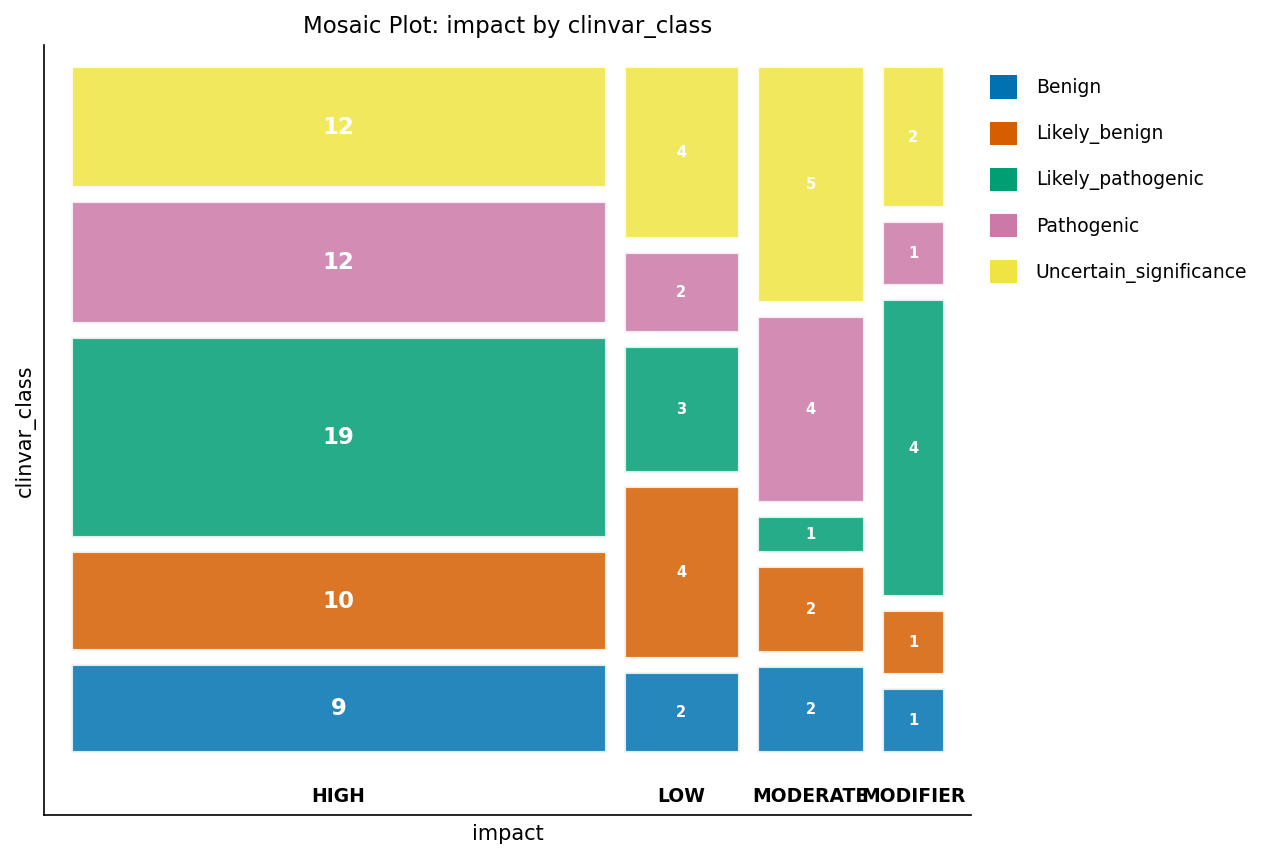

In [4]:
/* --------------------------------------------------------
   Základní souhrn anotací variant
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    NÁZEV 'Dopad variant podle klasifikace ClinVar';
SPUSTIT;

PROCEDURA PRŮMĚRY data=quality_metrics n mean MIN MAX;
    PROMĚNNÁ mean_coverage ti_tv_ratio contamination_est;
    NÁZEV 'Souhrn metrik kvality sekvenování';
SPUSTIT;

---

                                           Souhrn metrik kvality sekvenování                                            

                                           Souhrn metrik kvality sekvenování                                            




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


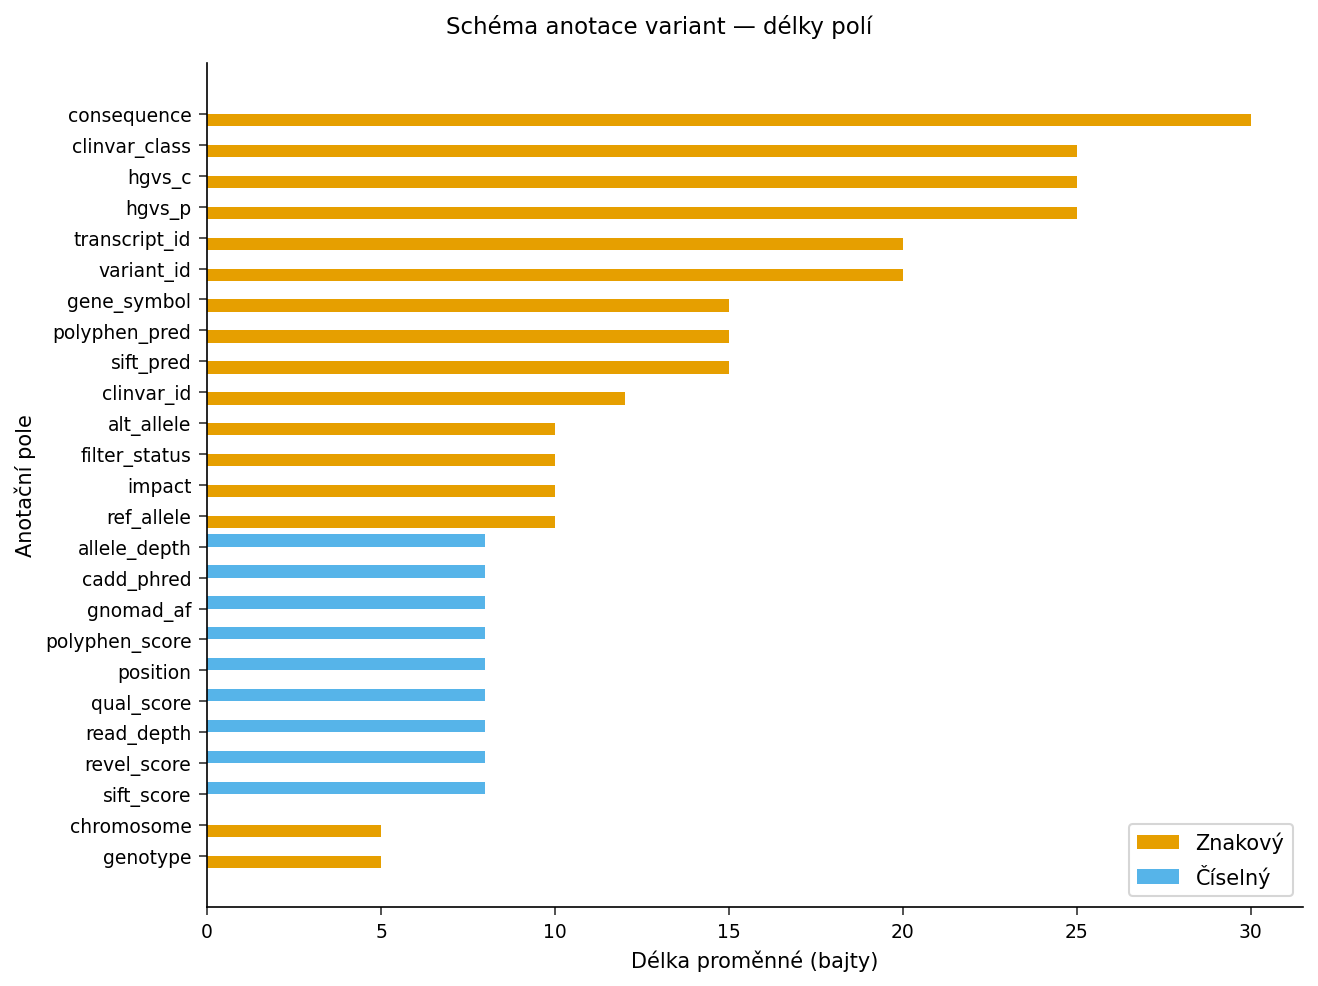

In [5]:
/* --------------------------------------------------------
   Variable type and length distribution.
   Capture the annotation schema metadata with PROC
   CONTENTS OUT=, then plot field lengths by type. TYPE
   codes map 1 -> Numeric, 2 -> Character for the legend.
   -------------------------------------------------------- */
PROCEDURA OBSAH data=variant_annotations out=schema_lengths NOPRINT;
SPUSTIT;

data schema_lengths;
    NASTAVIT schema_lengths;
    DÉLKA type_label $12;
    KDYŽ TYPE = 1 PAK type_label = 'Číselný';
    JINAK type_label = 'Znakový';
SPUSTIT;

PROCEDURA SGPLOT data=schema_lengths;
    HBAR NAME / RESPONSE=DÉLKA GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS ŠTÍTEK='Délka proměnné (bajty)';
    YAXIS ŠTÍTEK='Anotační pole';
    NÁZEV 'Schéma anotace variant — délky polí';
SPUSTIT;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: Zdokumentuj úplné schéma anotací variant
   — typy, délky a labely všech 25 polí. Zachyť metadata
   proměnných pomocí OUT=, aby navazující kroky mohly
   schéma programově validovat.
   -------------------------------------------------------- */
PROCEDURA OBSAH data=variant_annotations out=variant_schema NOPRINT;
SPUSTIT;

PROCEDURA TISK data=variant_schema;
    PROMĚNNÁ NAME TYPE DÉLKA VARNUM ŠTÍTEK;
    NÁZEV 'Datová sada anotace variant — úplné schéma';
SPUSTIT;

                                           Souhrn metrik kvality sekvenování                                            

                                       Datová sada anotace variant — úplné schéma                                       

  Obs            NAME  TYPE  LENGTH  VARNUM                            LABEL
    1  allele_depth       1       8      22  Hloubka alternativní alely
    2  alt_allele         2      10       5  Alternativní alela
    3  cadd_phred         1       8      19  Skóre CADD Phred
    4  chromosome         2       5       2  Chromozom
    5  clinvar_class      2      25      13  Klasifikace ClinVar
    6  clinvar_id         2      12      14  Přístupové číslo ClinVar
    7  consequence        2      30       8  Důsledek dle Sequence Ontology
    8  filter_status      2      10      25  Stav filtru
    9  gene_symbol        2      15       6  Symbol genu HGNC
   10  genotype           2       5      21  Genotyp vzorku
   11  gnomad_af          1       8 


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: Zdokumentuj schéma genového panelu
   -------------------------------------------------------- */
PROCEDURA OBSAH data=gene_panel out=panel_schema NOPRINT;
SPUSTIT;

PROCEDURA TISK data=panel_schema;
    PROMĚNNÁ NAME TYPE DÉLKA VARNUM ŠTÍTEK;
    NÁZEV 'Definice genového panelu — schéma';
SPUSTIT;

                                       Datová sada anotace variant — úplné schéma                                       

                                           Definice genového panelu — schéma                                            

  Obs                 NAME  TYPE  LENGTH  VARNUM                      LABEL
    1  chromosome              2       5       3  Chromozom
    2  disease_association     2      50       7  Asociované onemocnění
    3  end_pos                 1       8       5  Koncová pozice genu
    4  gene_name               2      60       2  Celý název genu
    5  gene_symbol             2      15       1  Symbol genu HGNC
    6  inheritance             2       5       8  Vzorec dědičnosti
    7  panel_name              2      30       6  Klinický genový panel
    8  start_pos               1       8       4  Počáteční pozice genu




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: Zdokumentuj schéma metrik QC
   -------------------------------------------------------- */
PROCEDURA OBSAH data=quality_metrics out=qc_schema NOPRINT;
SPUSTIT;

PROCEDURA TISK data=qc_schema;
    PROMĚNNÁ NAME TYPE DÉLKA VARNUM ŠTÍTEK;
    NÁZEV 'Metriky kvality sekvenování — schéma';
SPUSTIT;

                                           Definice genového panelu — schéma                                            

                                          Metriky kvality sekvenování — schéma                                          

  Obs               NAME  TYPE  LENGTH  VARNUM                        LABEL
    1  contamination_est     1       8      10  Odhadovaná kontaminace
    2  het_hom_ratio         1       8       9  Poměr het/hom
    3  mean_coverage         1       8       4  Průměrné pokrytí cíle
    4  pct_target_100x       1       8       6  Procento bází >= 100x
    5  pct_target_20x        1       8       5  Procento bází >= 20x
    6  platform              2      15       3  Platforma sekvenování
    7  qc_status             2      10      11  Stav QC (prošel/neprošel)
    8  run_id                2      12       2  ID běhu sekvenování
    9  sample_id             2      15       1  Identifikátor vzorku
   10  ti_tv_ratio           1       8       8  Poměr tra


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Schema validation: check that annotation fields
   meet pipeline requirements for ACMG interpretation.
   Reads the PROC CONTENTS OUT= metadata, where TYPE=1
   denotes numeric and TYPE=2 denotes character.
   -------------------------------------------------------- */
data schema_validation;
    NASTAVIT variant_schema;
    DÉLKA requirement $60 status $10;
    /* Numeric score fields must be stored as numeric (TYPE=1) */
    KDYŽ NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 PAK OPAKUJ;
        requirement = 'Musí být číselné pro prahové hodnoty skóre';
        status = 'FAIL';
    KONEC;
    JINAK KDYŽ NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 PAK OPAKUJ;
        requirement = 'Číselný typ potvrzen';
        status = 'PASS';
    KONEC;
    /* ClinVar class needs sufficient character length */
    JINAK KDYŽ NAME = 'clinvar_class' AND DÉLKA < 25 PAK OPAKUJ;
        requirement = 'Min. $25 pro úplný klasifikační text';
        status = 'FAIL';
    KONEC;
    JINAK KDYŽ NAME = 'clinvar_class' PAK OPAKUJ;
        requirement = 'Délka znakového pole dostačující';
        status = 'PASS';
    KONEC;
    /* All fields must carry a label for the data dictionary */
    JINAK KDYŽ ŠTÍTEK = '' PAK OPAKUJ;
        requirement = 'Label vyžadován pro datový slovník';
        status = 'FAIL';
    KONEC;
    JINAK OPAKUJ;
        requirement = 'Obecná validace';
        status = 'PASS';
    KONEC;
SPUSTIT;

PROCEDURA TISK data=schema_validation;
    PROMĚNNÁ NAME TYPE DÉLKA ŠTÍTEK requirement status;
    NÁZEV 'Zpráva o validaci schématu pipeline ACMG';
SPUSTIT;

                                        Zpráva o validaci schématu pipeline ACMG                                        

  Obs            NAME  TYPE  LENGTH                            LABEL                            requirement  status
    1  allele_depth       1       8  Hloubka alternativní alely       Číselný typ potvrzen                   PASS
    2  alt_allele         2      10  Alternativní alela               Obecná validace                        PASS
    3  cadd_phred         1       8  Skóre CADD Phred                 Číselný typ potvrzen                   PASS
    4  chromosome         2       5  Chromozom                        Obecná validace                        PASS
    5  clinvar_class      2      25  Klasifikace ClinVar              Délka znakového pole dostačující       PASS
    6  clinvar_id         2      12  Přístupové číslo ClinVar         Obecná validace                        PASS
    7  consequence        2      30  Důsledek dle Sequence Ontology   Obecná v


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Interpretace

Schéma anotací variant obsahuje 25 polí pokrývajících genomické souřadnice, funkční predikce, populační frekvence a ukazatele kvality pro jednotlivé vzorky. Všech devět číselných skórovacích polí (frekvence alely gnomAD, SIFT, PolyPhen-2, CADD, REVEL, skóre kvality, hloubka alely, hloubka čtení a genomická pozice) má správně přiřazený číselný typ, což enginu pro interpretaci podle ACMG umožňuje aplikovat prahové filtrování bez převodu typů. Pole clinvar_class s délkou $25 pojme nejdelší klasifikační řetězec ClinVar (Uncertain_significance o délce 24 znaků). Každé anotační pole nese popisný label, což splňuje požadavek klinické laboratoře na datový slovník podle akreditačních pravidel CAP. Schéma genového panelu mapuje 15 genů predisponujících k nádorům spolu se vzorci dědičnosti a asociacemi s onemocněními a poskytuje referenční rámec pro anotaci variant vůči genům. Datová sada metrik QC sekvenování dokumentuje 50 vzorků napříč 5 běhy, s odhady kontaminace a prahovými hodnotami pokrytí, které řídí spolehlivost volání variant. Tento dokumentační balíček schématu podporuje validační dokumentaci laboratoře pro podání New York State CLEP.

---

In [10]:
/* --------------------------------------------------------
   Exportuj dokumentaci schématu variant a
   validační zprávu pro akreditaci laboratoře
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Využívá <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>